In [117]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
path = r'../../data/limpieza/cleaned_data.csv'
df = pd.read_csv(path, header=0)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df

,timestamp,open_binance,high_binance,low_binance,close_binance,volume_binance,trades_binance,volumen_binance,SMA_50_binance,SMA_200_binance,...,volatilidad_200_dxy,momentum_50_dxy,momentum_200_dxy,var_diaria_dxy,rango_dia_dxy,RSI_dxy,pct_cambio_7d,tendencia_futura_7d,pct_cambio_30d,tendencia_futura_30d
0,2023-01-30,23743.37,23800.51,22500.00,22826.15,302405.90121,7790224.0,6.902762e+09,18840.4428,19681.15235,...,3.344820,-2.743332,-6.260002,0.114196,0.649994,48.159051,0.887539,1,15.651634,1
1,2023-01-31,22827.38,23320.00,22714.77,23125.13,264649.34909,6798411.0,6.120051e+09,18958.7488,19692.62780,...,3.365946,-3.029999,-5.959999,-0.175988,0.599998,42.076453,0.651979,1,14.475111,1
2,2023-02-01,23125.13,23812.66,22760.23,23732.66,310790.42271,7863213.0,7.375883e+09,19077.9080,19705.31310,...,3.394349,-2.760002,-6.609998,-0.861897,1.150002,28.731297,-0.237540,-1,12.944154,1
3,2023-02-02,23731.41,24255.00,23363.27,23488.94,364177.20751,9102300.0,8.554137e+09,19191.6238,19718.76700,...,3.417732,-2.019997,-5.850001,0.523611,1.090004,44.673560,-1.569186,-1,11.529444,1
4,2023-02-03,23489.33,23715.70,23204.62,23431.90,332571.02904,8007846.0,7.792771e+09,19313.1350,19723.76360,...,3.432184,-1.639999,-4.450005,1.149875,1.459999,61.290298,-2.890628,-1,10.208064,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,2025-02-05,97763.14,99149.00,96155.00,96612.43,26233.30444,4471763.0,2.534463e+09,98831.5984,78366.38690,...,2.801588,0.620003,3.210002,-0.351980,0.709999,43.123575,-3.443442,-1,-7.038993,-1
738,2025-02-06,96612.44,99120.00,95676.64,96554.35,23515.20405,4242807.0,2.270495e+09,98758.6052,78508.33195,...,2.808863,-0.339996,3.350004,0.102250,0.559998,45.794384,-2.297581,-1,-7.370303,-1
739,2025-02-07,96554.35,100137.99,95620.34,96506.80,31794.22065,5012456.0,3.068358e+09,98739.5040,78653.20590,...,2.817887,-0.370003,3.730003,0.325006,0.800003,57.462674,-1.310774,-1,-7.939256,-1
740,2025-02-08,96506.80,96880.00,95688.00,96444.74,10147.24294,1757892.0,9.786482e+08,98712.2900,78805.74955,...,2.827413,0.513331,3.683337,0.086387,0.650004,58.905243,-0.540410,-1,-8.600834,-1


# Visualización de la variable respuesta (7 días)

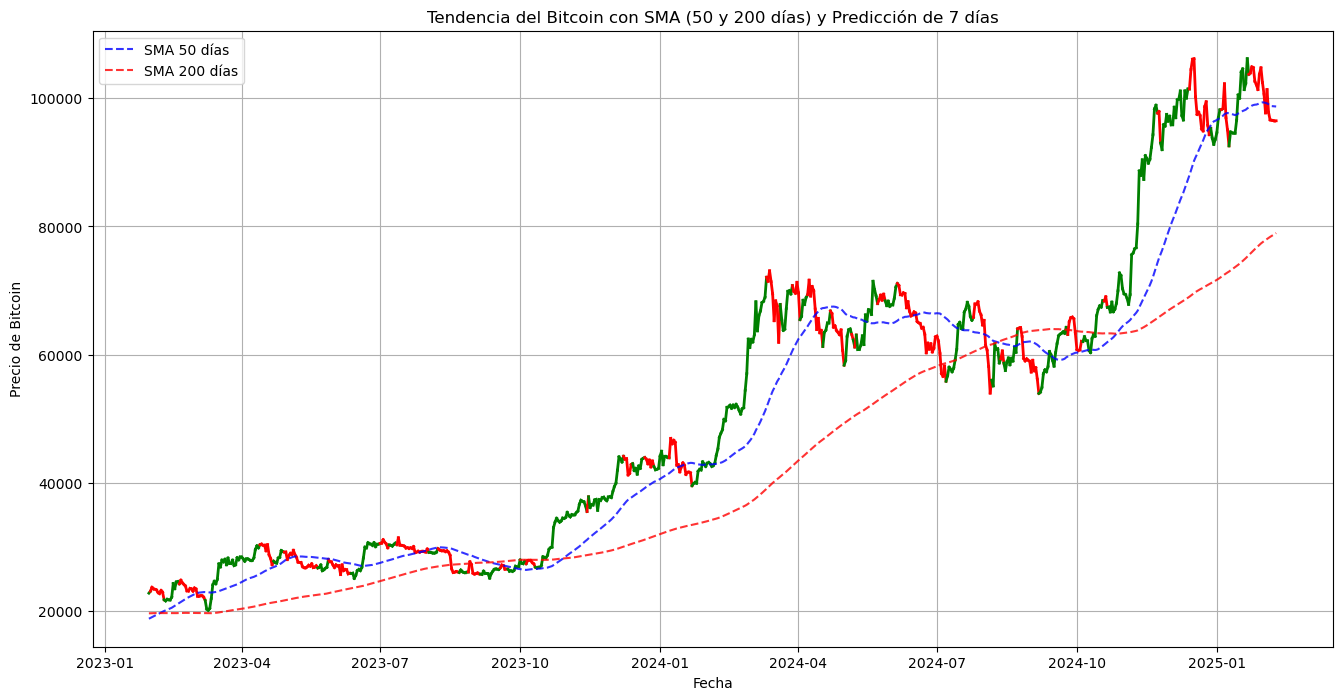

In [123]:
# Crear una visualización donde la línea de "close_binance" cambie de color según la tendencia futura
# Agregando un color adicional para la tendencia neutral

df_plot = df
# Configurar la figura
plt.figure(figsize=(16, 8))

# Recorrer el dataset para cambiar el color del precio de cierre según la tendencia
for i in range(1, len(df_plot)):
    if df_plot.iloc[i]['tendencia_futura_7d'] == 1:
        color = 'green'  # Alcista
    elif df_plot.iloc[i]['tendencia_futura_7d'] == -1:
        color = 'red'  # Bajista
    else:
        color = 'gray'  # Neutral

    plt.plot(df_plot['timestamp'].iloc[i-1:i+1], df_plot['close_binance'].iloc[i-1:i+1], color=color, linewidth=2)

# Graficar las medias móviles
plt.plot(df_plot['timestamp'], df_plot['SMA_50_binance'], label="SMA 50 días", linestyle="dashed", color="blue", alpha=0.8)
plt.plot(df_plot['timestamp'], df_plot['SMA_200_binance'], label="SMA 200 días", linestyle="dashed", color="red", alpha=0.8)

# Configuración de la gráfica
plt.xlabel("Fecha")
plt.ylabel("Precio de Bitcoin")
plt.title("Tendencia del Bitcoin con SMA (50 y 200 días) y Predicción de 7 días")
plt.legend()
plt.grid()

# Mostrar la gráfica mejorada con colores en la línea de precio
plt.show()

# Visualización de la volatilidad de la variable respuesta a 7 días

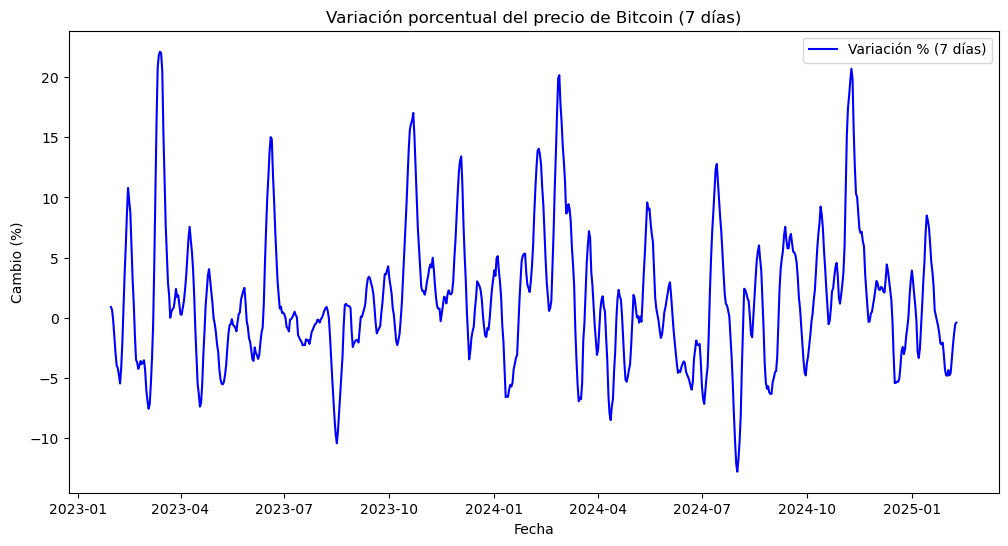

In [125]:
horizonte = 7 

# Asegurarse de que 'timestamp' es índice y en formato datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

# Visualizar la serie temporal de la variación porcentual
plt.figure(figsize=(12,6))
plt.plot(df.index, df[f'pct_cambio_{horizonte}d'], label=f'Variación % ({horizonte} días)', color='blue')
plt.title(f'Variación porcentual del precio de Bitcoin ({horizonte} días)')
plt.xlabel('Fecha')
plt.ylabel('Cambio (%)')
plt.legend()
plt.show()

**Conclusión**: La gráfica anterior representa la evolución temporal de la variable objetivo pct_cambio_7d, que mide el porcentaje de cambio del precio del Bitcoin en intervalos de 7 días consecutivos. Esta visualización permite apreciar la naturaleza altamente volátil de la variable respuesta, con oscilaciones frecuentes entre valores positivos y negativos. Se observan picos bruscos de crecimiento y caídas, reflejo de la inestabilidad inherente al mercado de criptomonedas. La serie no presenta una tendencia clara ni patrones visualmente recurrentes, lo que refuerza la complejidad del problema de predicción. Esta alta fluctuación sugiere que el modelo deberá ser capaz de adaptarse a movimientos abruptos y dinámicas cambiantes en cortos periodos de tiempo.

# Exploración de la estructura temporal de la variable respuesta a 7 días

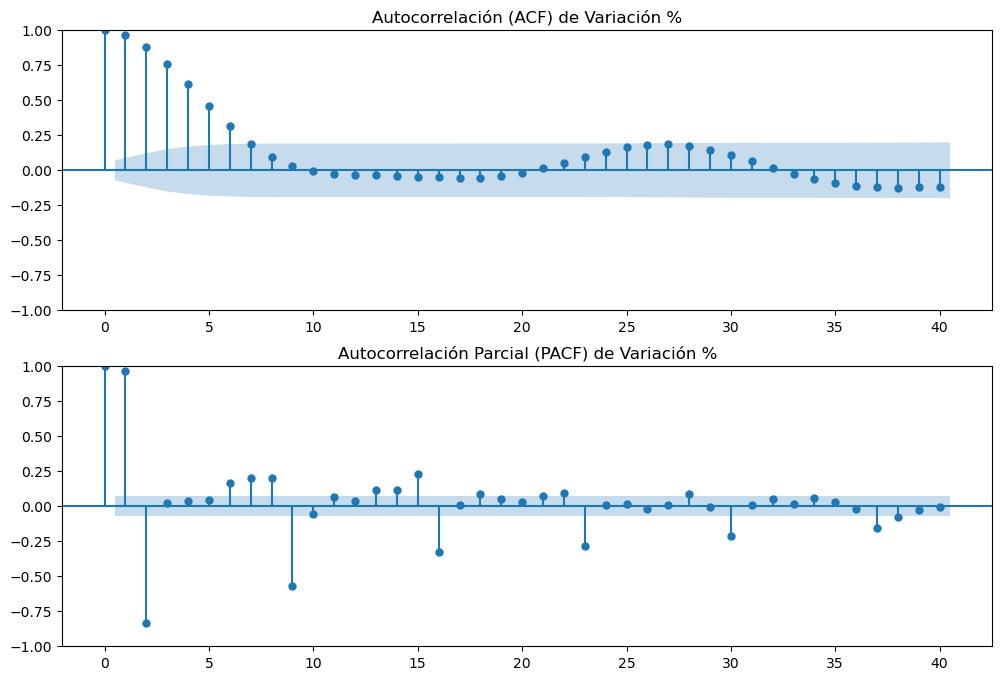

In [127]:
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(df[f'pct_cambio_{horizonte}d'].dropna(), ax=ax[0], lags=40)  # ACF hasta 40 retrasos
plot_pacf(df[f'pct_cambio_{horizonte}d'].dropna(), ax=ax[1], lags=40) # PACF hasta 40 retrasos
ax[0].set_title("Autocorrelación (ACF) de Variación %")
ax[1].set_title("Autocorrelación Parcial (PACF) de Variación %")
plt.show()

**Conclusiones**: En esta sección hemos analizado la posible existencia de dependencia temporal en la variable objetivo pct_cambio_7d, es decir, si los valores pasados de la serie influyen en su comportamiento futuro. La intuición detrás de este análisis es que lo que ocurrió en días o semanas anteriores podría tener un efecto sobre lo que ocurrirá en los próximos días. Los resultados del análisis de autocorrelación muestran que existe una relación temporal significativa en los primeros lags, lo que indica que la variable no es completamente aleatoria y que podría ser parcialmente predecible a corto plazo. No obstante, el comportamiento altamente volátil y abrupto de la serie implica que, aunque exista cierta estructura, predecir con precisión los cambios semanales sigue siendo una tarea compleja. Por ello, los modelos que se utilicen deberán ser capaces de capturar patrones sutiles y adaptarse a cambios frecuentes en la dinámica del mercado.

# Análisis estructural de la variable respuesta a 7 días: tendencia y estacionalidad

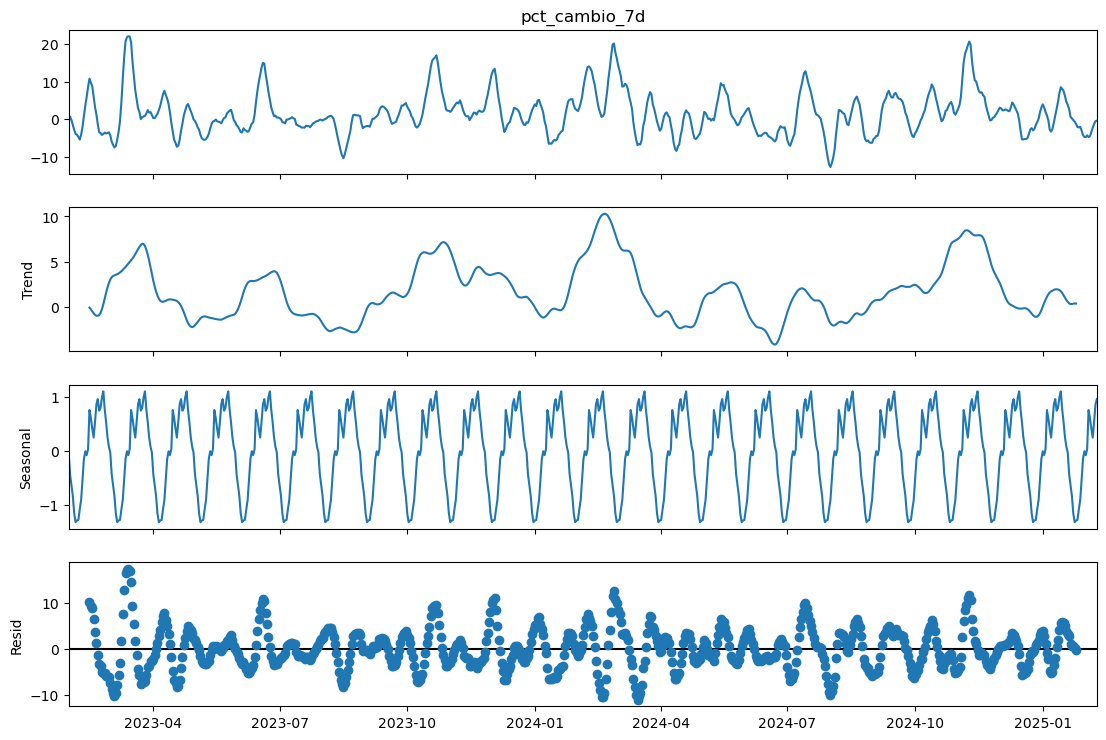

In [129]:
decomposition = sm.tsa.seasonal_decompose(df[f'pct_cambio_{horizonte}d'].dropna(), model='additive', period=30)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

**Conclusión**: La descomposición estacional de la variable pct_cambio_7d permite estudiar su estructura interna separando los componentes de tendencia, estacionalidad y ruido. En la primera gráfica se observa de nuevo la alta volatilidad de la serie original, con picos pronunciados tanto positivos como negativos. La componente de tendencia revela movimientos más suaves y sostenidos a lo largo del tiempo, lo que sugiere que, aunque a corto plazo el comportamiento es errático, pueden existir fases de crecimiento o caída más prolongadas. Por otro lado, la componente estacional muestra un patrón cíclico claro, lo que indica que existen fluctuaciones recurrentes en la serie con cierta regularidad (posiblemente semanal o mensual). Finalmente, la componente residual contiene variaciones abruptas y aparentemente aleatorias, que representan la parte impredecible del mercado. En conjunto, esta descomposición confirma que la variable respuesta no es completamente aleatoria: contiene elementos estructurados que los modelos pueden intentar capturar, aunque siempre existirá una parte residual de alta incertidumbre debido a la naturaleza impredecible del mercado de criptomonedas.

# Visualización de la variable respuesta (30 días)

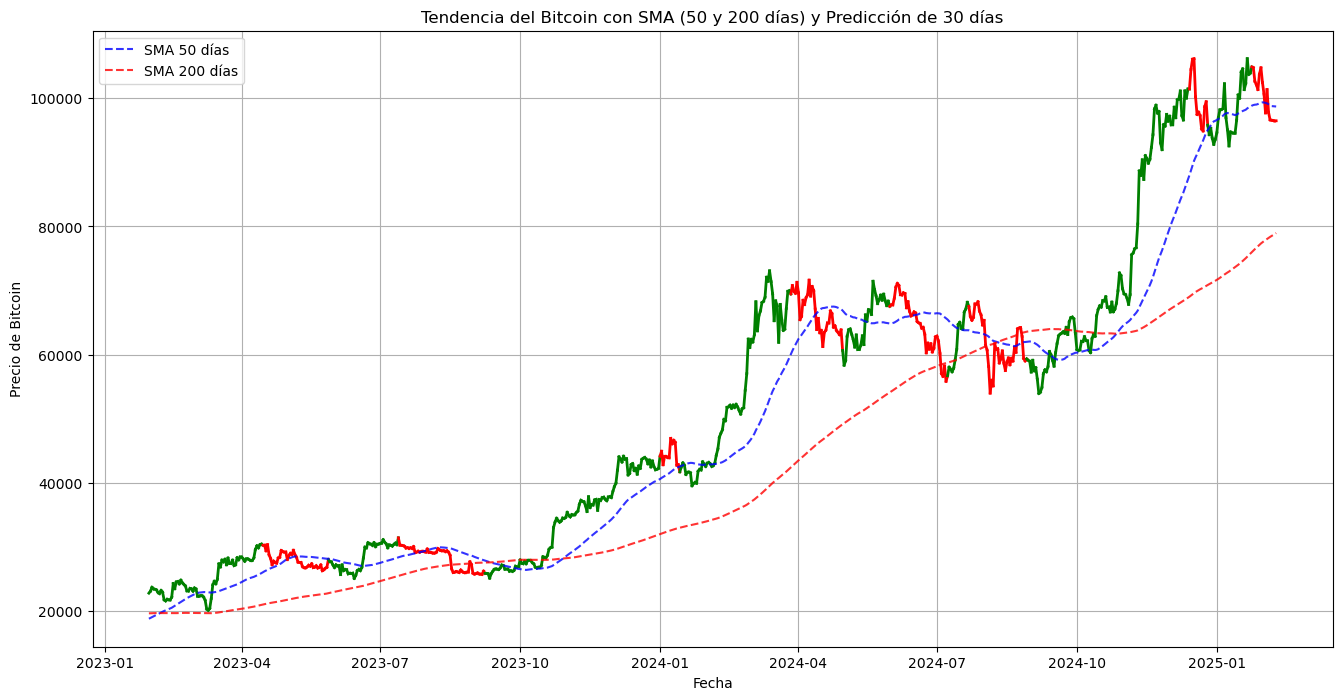

In [133]:
# Crear una visualización donde la línea de "close_binance" cambie de color según la tendencia futura a 30 días
path = r'../../data/limpieza/cleaned_data.csv'
df = pd.read_csv(path, header=0)
df['timestamp'] = pd.to_datetime(df['timestamp'])

df_plot = df.copy()

plt.figure(figsize=(16, 8))

# Recorrer el dataset para cambiar el color del precio de cierre según la tendencia futura a 30 días
for i in range(1, len(df_plot)):
    if df_plot.iloc[i]['tendencia_futura_30d'] == 1:
        color = 'green'  # Alcista
    elif df_plot.iloc[i]['tendencia_futura_30d'] == -1:
        color = 'red'  # Bajista
    else:
        color = 'gray'  # Neutral

    plt.plot(df_plot['timestamp'].iloc[i-1:i+1], df_plot['close_binance'].iloc[i-1:i+1], color=color, linewidth=2)

# Graficar las medias móviles
plt.plot(df_plot['timestamp'], df_plot['SMA_50_binance'], label="SMA 50 días", linestyle="dashed", color="blue", alpha=0.8)
plt.plot(df_plot['timestamp'], df_plot['SMA_200_binance'], label="SMA 200 días", linestyle="dashed", color="red", alpha=0.8)

# Configuración de la gráfica
plt.xlabel("Fecha")
plt.ylabel("Precio de Bitcoin")
plt.title("Tendencia del Bitcoin con SMA (50 y 200 días) y Predicción de 30 días")
plt.legend()
plt.grid()

plt.show()


# Visualización de la volatilidad de la variable respuesta a 30 días

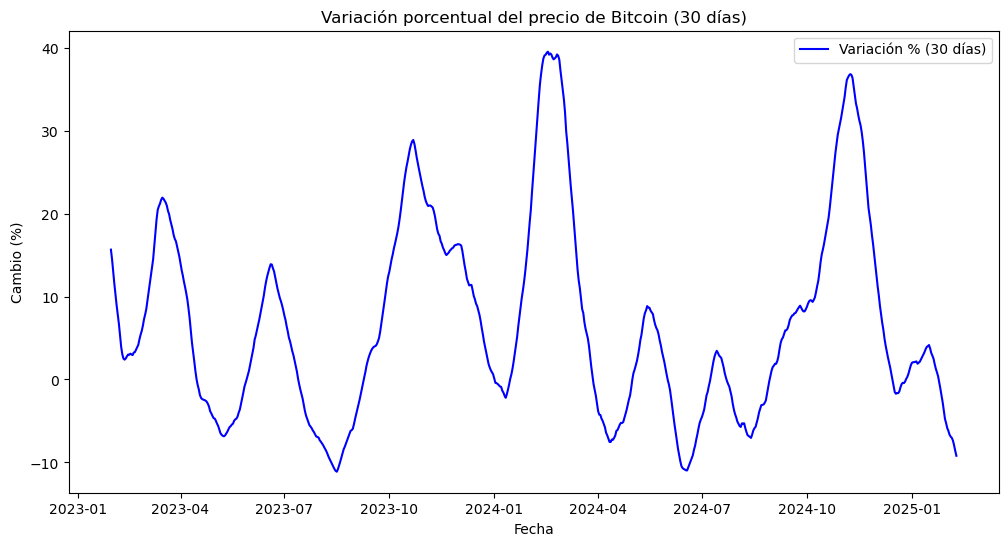

In [135]:
horizonte = 30 

# Asegurarse de que 'timestamp' es índice y en formato datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

# Visualizar la serie temporal de la variación porcentual
plt.figure(figsize=(12,6))
plt.plot(df.index, df[f'pct_cambio_{horizonte}d'], label=f'Variación % ({horizonte} días)', color='blue')
plt.title(f'Variación porcentual del precio de Bitcoin ({horizonte} días)')
plt.xlabel('Fecha')
plt.ylabel('Cambio (%)')
plt.legend()
plt.show()

**Conclusión**: La evolución temporal de la variable pct_cambio_30d, que representa el cambio porcentual del precio de Bitcoin en intervalos de 30 días, revela un comportamiento diferente al observado en pct_cambio_7d. Aunque ambas series muestran variaciones frecuentes entre valores positivos y negativos, la serie a 30 días presenta oscilaciones más amplias y definidas, con picos más extremos (por encima del 40 %) y ciclos más suaves. Esto sugiere que, al agrupar la información en intervalos más largos, se filtra parte del ruido presente en los cambios semanales, y emergen patrones más sostenidos en el tiempo.

# Exploración de la estructura temporal de la variable respuesta a 30 días

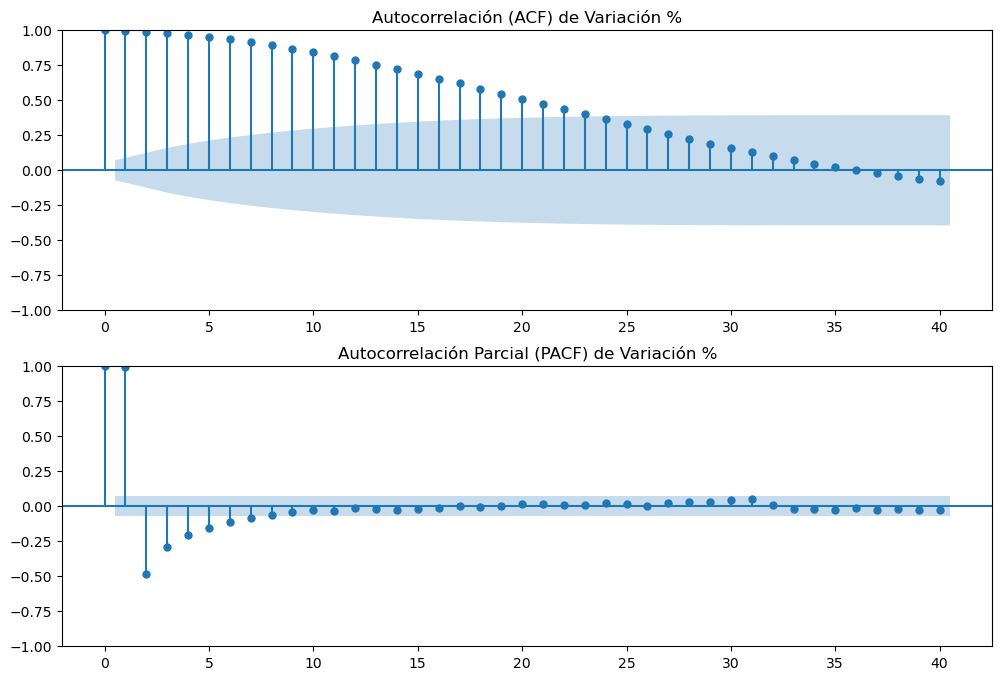

In [137]:
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(df[f'pct_cambio_{horizonte}d'].dropna(), ax=ax[0], lags=40)  # ACF hasta 40 retrasos
plot_pacf(df[f'pct_cambio_{horizonte}d'].dropna(), ax=ax[1], lags=40) # PACF hasta 40 retrasos
ax[0].set_title("Autocorrelación (ACF) de Variación %")
ax[1].set_title("Autocorrelación Parcial (PACF) de Variación %")
plt.show()

**Conclusción**: En este apartado se ha examinado la posible dependencia temporal de la variable pct_cambio_30d, es decir, si los valores anteriores de la serie pueden ayudar a explicar o anticipar sus valores futuros. El análisis de autocorrelación (ACF) muestra una caída progresiva más lenta que en el caso de pct_cambio_7d, con correlaciones significativas extendiéndose más allá del lag 20. Esto sugiere que, en horizontes más largos, la serie presenta una memoria temporal más prolongada, lo cual tiene sentido si se considera que los movimientos de precio en 30 días suelen reflejar acumulaciones de comportamiento del mercado en el tiempo. La PACF también muestra contribuciones relevantes en varios lags, aunque decrecientes, lo que refuerza la idea de que la variable conserva estructura interna útil para el modelado.

Comparando este comportamiento con el observado en el análisis de 7 días, se aprecia que la serie a 30 días es menos errática y más estructurada, lo que podría facilitar su predicción con modelos adecuados. Sin embargo, sigue estando sujeta a la volatilidad propia del mercado de criptomonedas, por lo que cualquier modelo deberá ser capaz de capturar tanto patrones temporales como posibles comportamientos extremos.

# Análisis estructural de la variable respuesta a 30 días: tendencia y estacionalidad

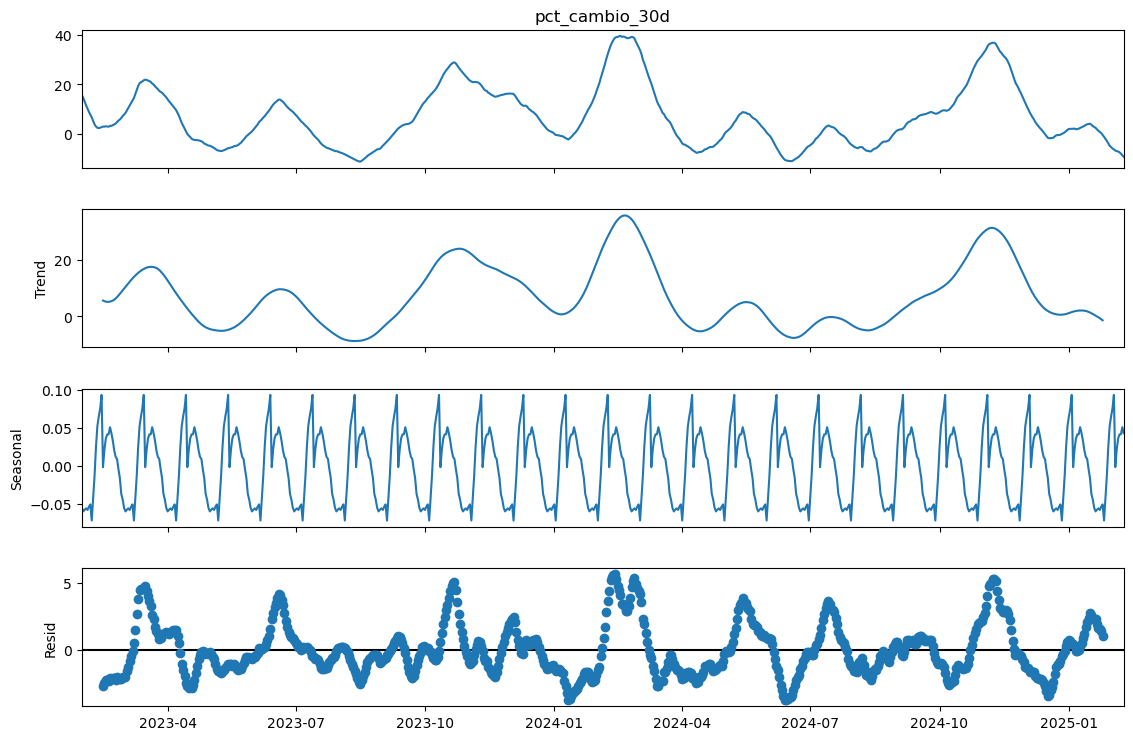

In [139]:
decomposition = sm.tsa.seasonal_decompose(df[f'pct_cambio_{horizonte}d'].dropna(), model='additive', period=30)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

**Conclusión**: La descomposición de pct_cambio_30d permite observar una componente de tendencia más clara y sostenida en comparación con la de 7 días. Se aprecian fases de crecimiento y caída que se prolongan durante varios meses, lo que indica que en horizontes más largos los movimientos del mercado tienden a organizarse en ciclos más estables. La estacionalidad también está presente, aunque de magnitud muy reducida, con un patrón periódico que podría reflejar efectos semanales o mensuales, pero que queda diluido frente a la variabilidad general de la serie. Por otro lado, la componente residual muestra menor dispersión y presencia de extremos respecto a la descomposición de 7 días, lo que sugiere que parte del ruido de corto plazo queda absorbido en la tendencia o en los movimientos acumulados.

En conjunto, al comparar ambas descomposiciones, se observa que pct_cambio_30d conserva cierta estructura interna más estable, lo que puede facilitar la modelización en términos de tendencias amplias. En contraste, la descomposición de pct_cambio_7d revela una mayor presencia de componentes impredecibles en el residuo, reflejo de una dinámica más volátil e inmediata. Estas diferencias refuerzan la necesidad de tratar ambos horizontes de predicción como problemas distintos, tanto en enfoque como en dificultad.